# Regression using Simple Neural Network

In [1]:
import torch
print(torch.__version__)

2.8.0


In [2]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

# Setting up seed ensures results are reproducible and consistent across runs
torch.manual_seed(25)

## Step 1: Data Preparation

We'll load real-world housing data from a CSV file and prepare it for training.

In [3]:
# Load real-world housing data from CSV file
import pandas as pd

# Read the dataset
df = pd.read_csv('/Users/akshay/Work/data/housing_data/train.csv')

# Filter data to reasonable house sizes (500-5000 sqft)
df = df[(df['SQUARE_FT'] <= 5000) & (df['SQUARE_FT'] >= 500)]
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


Single feature is not sufficient in real-world setting to make accurate prediction. For better prediction model, we will use other features as well. 

The price of an apartment is dependant on multiplle features like how many bedrooms (BHK_NO), goverment approved or not (RERA), Ready to move or under_construction (READY_TO_MOVE), and resale value (RESALE). We will be using all of these features together for learning the price prediction model.

In [4]:
# Select relevant features for the model
df = df[['SQUARE_FT', 'BHK_NO.', 'RERA', 'READY_TO_MOVE', 'TARGET(PRICE_IN_LACS)']]
df.head()

,SQUARE_FT,BHK_NO.,RERA,READY_TO_MOVE,TARGET(PRICE_IN_LACS)
0,1300.236407,2,0,1,55.0
1,1275.000000,2,0,1,51.0
2,933.159722,2,0,1,43.0
3,929.921143,2,1,1,62.5
4,999.009247,2,0,0,60.5


### Visualizing the Data

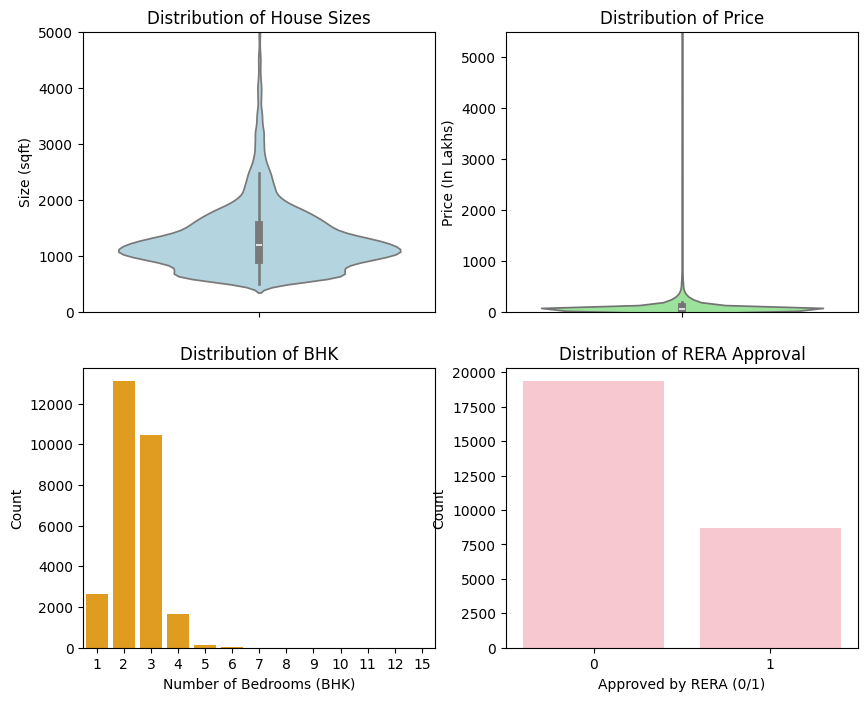

In [5]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Violin plot showing distribution of house sizes
sns.violinplot(y=df['SQUARE_FT'], ax=axes[0, 0], color='lightblue')
axes[0, 0].set_ylim(0, df['SQUARE_FT'].max())
axes[0, 0].set_ylabel('Size (sqft)')
axes[0, 0].set_title('Distribution of House Sizes')

sns.violinplot(y=df['TARGET(PRICE_IN_LACS)'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_ylim(0, df['TARGET(PRICE_IN_LACS)'].max())
axes[0, 1].set_ylabel('Price (In Lakhs)')
axes[0, 1].set_title('Distribution of Price')

sns.countplot(x=df['BHK_NO.'], ax=axes[1, 0], color='orange')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Number of Bedrooms (BHK)')
axes[1, 0].set_title('Distribution of BHK')

sns.countplot(x=df['RERA'], ax=axes[1, 1], color='pink')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Approved by RERA (0/1)')
axes[1, 1].set_title('Distribution of RERA Approval')
plt.show()

### Preparing the Data

Prepare the data using the function above. This returns normalized features (X) and targets (y), along with original tensors for denormalization later.


Inspect the input features (X) - shape should be [N, 4] where N is number of samples and 4 is number of features.


Inspect the target values (y) - normalized prices with shape [N, 1].


In [6]:
def prepare_data(df):
    # Convert DataFrame to NumPy array, then to PyTorch tensor
    all_data = df.values
    all_tensors = torch.tensor(all_data, dtype=torch.float32)

    # Separate each column into its own tensor and reshape to column vector [N, 1]
    size_tensor = all_tensors[:,0].unsqueeze(1)
    bhk_tensor = all_tensors[:,1].unsqueeze(1)
    rera_tensor = all_tensors[:,2].unsqueeze(1)
    ready_to_move_tensor = all_tensors[:,3].unsqueeze(1)
    price_tensor = all_tensors[:,4].unsqueeze(1)

    # Normalize continuous variables (size and price) 
    size_norm = (size_tensor - size_tensor.mean()) / size_tensor.std()
    price_norm = (price_tensor - price_tensor.mean()) / price_tensor.std()

    # Concatenate all input features: normalized size + categorical features
    X = torch.cat([size_norm, bhk_tensor, rera_tensor, ready_to_move_tensor], dim=1)
    y = price_norm  # Target is normalized price

    return X, y, size_tensor, price_tensor, size_norm, price_norm


In [7]:
X, y, size_tensor, price_tensor, size_norm, price_norm = prepare_data(df)

In [8]:
X

tensor([[-0.0263,  2.0000,  0.0000,  1.0000],
        [-0.0674,  2.0000,  0.0000,  1.0000],
        [-0.6236,  2.0000,  0.0000,  1.0000],
        ...,
        [-0.4780,  2.0000,  0.0000,  1.0000],
        [-0.6335,  2.0000,  0.0000,  1.0000],
        [-0.6828,  2.0000,  1.0000,  1.0000]])

In [9]:
y

tensor([[-0.2989],
        [-0.3256],
        [-0.3789],
        ...,
        [-0.4849],
        [-0.2189],
        [-0.4802]])

## Step 2: Define the Neural Network Model

For non-linear relationships, we'll use a multi-layer network with an activation function (ReLU) between layers.

We'll use `nn.Sequential` with multiple layers:
- **Input layer**: `nn.Linear(4, 64)` - 4 input features → 64 hidden neurons
- **First hidden layer**: `nn.Linear(64, 32)` - 64 neurons → 32 neurons
- **Output layer**: `nn.Linear(32, 1)` - 32 neurons → 1 output value
- ReLU activation functions between layers introduce non-linearity

In [10]:
# Create a neural network with hidden layer for non-linear patterns
model = nn.Sequential(
    # Input layer (Linear): 4 input features, 64 output features
    nn.Linear(4, 64),
    # First ReLU activation function
    nn.ReLU(),
    # Hidden layer (Linear): 64 inputs, 32 outputs
    nn.Linear(64, 32),
    # Second ReLU activation function
    nn.ReLU(),
    # Output layer (Linear): 32 inputs, 1 output (the prediction)        
    nn.Linear(32, 1)   
)
model

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

#### Device managemt

In PyTorch, device management allows you to specify whether computations should be performed on a CPU or GPU. Using a GPU can significantly speed up training and inference for large models or datasets. The `torch.device` object is used to define the target device.

The code typically checks if a GPU is available using `torch.cuda.is_available()` for nvidia GPUs and `torch.backends.mps.is_available()` for mac GPUs and defaults to the CPU if no GPU is detected.


In [11]:
# device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [ ]:
# Move model to the selected device (CPU or GPU)
model.to(device)

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

## Step 3: Define Loss Function and Optimizer

- **Loss Function**: Measures the difference between predictions and actual values
- **Optimizer**: Updates model parameters (weights and biases) to minimize the loss
    - **Learning Rate**: Controls how much the optimizer adjusts parameters in each step

In [13]:
loss_fn = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent Optimizer

## Step 4: Training Loop

The training loop repeats the following steps for multiple epochs:
1. Reset gradients: Clear gradients from previous epochs
2. Forward pass: Make predictions
3. Calculate loss: Compare predictions with targets
4. Backward pass: Compute gradients
5. Update parameters: Adjust weights and biases

In [ ]:
def train_model(features, targets, model, optimizer, loss_fn, max_epochs=10000):
    """
    Train the neural network model.
    
    Returns:
        model: Trained model
        mean_loss: Average training loss across all epochs
    """
    # make sure model is in training mode
    model.train()
    loss_history = []

    for epoch in range(max_epochs):
        # Reset gradients to zero (gradients accumulate by default)
        optimizer.zero_grad()

        # Forward pass: Make predictions
        # Move features to the selected device (CPU or GPU)
        predicted_price = model(features.to(device))
        
        # Calculate loss: Compare predictions with normalized targets
        # Move targets to the selected device (CPU or GPU)
        loss = loss_fn(predicted_price, targets.to(device))
        loss_history.append(loss.item())

        # Backward pass: Compute gradients
        loss.backward()

        # Update model parameters using computed gradients
        optimizer.step()

        # Print progress every 1000 epochs
        if (epoch+1) % 1000 == 0:
            print(f'Epoch [{epoch+1}/{max_epochs}] | Loss: {loss.item():.4f}')
    
    return model, np.mean(loss_history)

In [15]:
model, train_loss = train_model(X, y, model, optimizer, loss_fn, max_epochs=10000)
print(f'Mean Training Loss: {train_loss:.4f}')

Epoch [1000/10000] | Loss: 0.7513
Epoch [2000/10000] | Loss: 0.7487
Epoch [3000/10000] | Loss: 0.7476
Epoch [4000/10000] | Loss: 0.7470
Epoch [5000/10000] | Loss: 0.7464
Epoch [6000/10000] | Loss: 0.7460
Epoch [7000/10000] | Loss: 0.7456
Epoch [8000/10000] | Loss: 0.7453
Epoch [9000/10000] | Loss: 0.7451
Epoch [10000/10000] | Loss: 0.7449
Mean Training Loss: 0.7490


## Step 5: Making Predictions

Use the trained model to predict prices for new house sizes. Use `torch.no_grad()` to disable gradient computation during inference (saves memory and computation).

### Example Prediction

What is the predicted price for a house with:
- Size: 2400 sqft
- Bedrooms: 3 BHK
- RERA approved: Yes (1)
- Ready to move: No (0)

In [16]:
# Create input features for prediction
house_size = torch.tensor([[2400.0]], dtype=torch.float32)

# Normalize the house size using same mean and std from training data
house_size_norm = (house_size - size_tensor.mean()) / size_tensor.std()

# Other features (categorical, no normalization needed)
bhk_no = torch.tensor([[3.0]], dtype=torch.float32)
rera = torch.tensor([[1.0]], dtype=torch.float32)  # 1 = RERA approved
ready_to_move = torch.tensor([[0.0]], dtype=torch.float32)  # 0 = not ready to move

# Concatenate all features in the same order as training data
input_tensor = torch.cat([house_size_norm, bhk_no, rera, ready_to_move], dim=1)


In [ ]:
# Make prediction without computing gradients (faster and uses less memory)
def predict_price(model, input_tensor):
    """
    Predict house price using trained model.
    
    Args:
        model: Trained neural network model
        input_tensor: Normalized input features [1, 4]
    
    Returns:
        Denormalized predicted price
    """
    # model.eval() set the model to evaluation mode (does not evaluate model)
    model.eval()
    with torch.no_grad(): # Disable gradient calculation/tracking
        # Model outputs normalized price
        # Move input tensor to the selected device (CPU or GPU)
        predicted_price = model(input_tensor.to(device))
        
        # Denormalize: convert back to original scale
        predicted_price_actual = predicted_price * price_tensor.std() + price_tensor.mean()
        
        return predicted_price_actual

In [18]:
predicted_price_actual = predict_price(model, input_tensor)
print(f'Predicted price for {house_size.item()} SQFT {bhk_no.item()} BHK {"RERA approved" if rera.item() == 1.0 else "RERA approval pending"} {"Ready to move" if ready_to_move.item() == 1.0 else "Under Construction"} apartment is {predicted_price_actual.item():.2f} LAKHS')

Predicted price for 2400.0 SQFT 3.0 BHK RERA approved Under Construction apartment is 183.22 LAKHS
